# Data Collection, 360 Feature Processing & Exploratory Data Analysis (EDA)



## Step 1: Environment Setup & Library Imports

In [1]:
# Install required packages if not already installed
%pip install -q statsbombpy mplsoccer seaborn pandas numpy matplotlib scipy scikit-learn shap

import os
import sys
import json
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from statsbombpy import sb

warnings.filterwarnings('ignore')

# Set professional aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8

# Robust root directory resolution (works whether running from root or inside Notebooks/)
if os.path.exists('data') and os.path.exists('figures'):
    PROJECT_ROOT = os.getcwd()
elif os.path.exists(os.path.join('..', 'data')) and os.path.exists(os.path.join('..', 'figures')):
    PROJECT_ROOT = os.path.abspath('..')
else:
    PROJECT_ROOT = os.getcwd()

DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
FIG_DIR = os.path.join(PROJECT_ROOT, 'figures')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print(f"✓ Environment initialized. Using project root at: {PROJECT_ROOT}")


Note: you may need to restart the kernel to use updated packages.


✓ Environment initialized. Using project root at: /Users/prova/Documents/cse490d-project


## Step 2: Pitch Drawing Utility (Standard 120 x 80 Yard Coordinate System)

In [2]:
def draw_pitch(ax, pitch_color='#f8f9fa', line_color='#333333'):
    """Draw a standard StatsBomb pitch (120 x 80 yards)"""
    ax.set_facecolor(pitch_color)
    # Pitch boundary
    ax.plot([0, 120, 120, 0, 0], [0, 0, 80, 80, 0], color=line_color, lw=1.5)
    # Halfway line
    ax.plot([60, 60], [0, 80], color=line_color, lw=1.2)
    # Center circle & spot
    center_circle = plt.Circle((60, 40), 10, color=line_color, fill=False, lw=1.2)
    center_spot = plt.Circle((60, 40), 0.8, color=line_color)
    ax.add_patch(center_circle)
    ax.add_patch(center_spot)
    
    # Left Penalty Area & 6-yard box
    ax.plot([0, 18, 18, 0], [18, 18, 62, 62], color=line_color, lw=1.2)
    ax.plot([0, 6, 6, 0], [30, 30, 50, 50], color=line_color, lw=1.0)
    left_pen_spot = plt.Circle((12, 40), 0.8, color=line_color)
    ax.add_patch(left_pen_spot)
    left_arc = patches.Arc((12, 40), 20, 20, angle=0, theta1=308, theta2=52, color=line_color, lw=1.2)
    ax.add_patch(left_arc)
    
    # Right Penalty Area & 6-yard box
    ax.plot([120, 102, 102, 120], [18, 18, 62, 62], color=line_color, lw=1.2)
    ax.plot([120, 114, 114, 120], [30, 30, 50, 50], color=line_color, lw=1.0)
    right_pen_spot = plt.Circle((108, 40), 0.8, color=line_color)
    ax.add_patch(right_pen_spot)
    right_arc = patches.Arc((108, 40), 20, 20, angle=0, theta1=128, theta2=232, color=line_color, lw=1.2)
    ax.add_patch(right_arc)
    
    # Goals
    ax.plot([-2, 0, 0, -2], [36, 36, 44, 44], color=line_color, lw=1.5)
    ax.plot([122, 120, 120, 122], [36, 36, 44, 44], color=line_color, lw=1.5)
    
    ax.set_xlim(-5, 125)
    ax.set_ylim(-5, 85)
    ax.set_aspect('equal')
    ax.axis('off')

print("✓ Pitch drawing engine defined.")


✓ Pitch drawing engine defined.


## Step 3: Positional 360 Geometry Feature Extraction
Computes:
* **Distance & Angle to Goal**
* **Closest Opponent Proximity** ($d_{\text{opp\_min}}$)
* **High-Intensity Defensive Pressure Rings** ($<3\text{m}$ and $<5\text{m}$)
* **Defenders in Goal Cone** ($N_{\text{cone}}$) via Barycentric coordinates
* **Forward Passing Options** ($N_{\text{forward\_opt}}$).


In [3]:
def calculate_angle_and_distance_to_goal(x, y, goal_x=120, goal_y=40):
    dx = goal_x - x
    dy = goal_y - y
    dist = math.sqrt(dx**2 + dy**2)
    angle = math.atan2(abs(dy), dx) if dx > 0 else 0
    return dist, angle

def process_360_frame_features(frame_df, event_x, event_y):
    """Extract spatial context from a StatsBomb 360 freeze frame."""
    if frame_df is None or frame_df.empty:
        return {
            'has_360': False,
            'teammates_visible': np.nan,
            'opponents_visible': np.nan,
            'total_visible': np.nan,
            'closest_opp_dist': np.nan,
            'closest_teammate_dist': np.nan,
            'opponents_within_3m': np.nan,
            'opponents_within_5m': np.nan,
            'defenders_in_goal_cone': np.nan,
            'forward_passing_options': np.nan
        }
    
    teammates = []
    opponents = []
    
    for _, row in frame_df.iterrows():
        loc = row.get('location')
        if not isinstance(loc, (list, tuple, np.ndarray)) or len(loc) < 2:
            continue
        px, py = loc[0], loc[1]
        is_teammate = bool(row.get('teammate', False))
        is_actor = bool(row.get('actor', False))
        
        if is_actor:
            continue
        
        if is_teammate:
            teammates.append((px, py))
        else:
            opponents.append((px, py))
            
    n_team = len(teammates)
    n_opp = len(opponents)
    total_vis = n_team + n_opp
    
    opp_dists = [math.sqrt((px - event_x)**2 + (py - event_y)**2) for px, py in opponents] if opponents else []
    team_dists = [math.sqrt((px - event_x)**2 + (py - event_y)**2) for px, py in teammates] if teammates else []
    
    closest_opp = min(opp_dists) if opp_dists else np.nan
    closest_team = min(team_dists) if team_dists else np.nan
    
    opp_3m = sum(1 for d in opp_dists if d <= 3.28) # ~3m
    opp_5m = sum(1 for d in opp_dists if d <= 5.46) # ~5m
    
    def is_in_goal_cone(px, py):
        if px < event_x:
            return False
        p1 = (120, 36)
        p2 = (120, 44)
        v0 = (p2[0] - event_x, p2[1] - event_y)
        v1 = (p1[0] - event_x, p1[1] - event_y)
        v2 = (px - event_x, py - event_y)
        
        dot00 = v0[0]*v0[0] + v0[1]*v0[1]
        dot01 = v0[0]*v1[0] + v0[1]*v1[1]
        dot02 = v0[0]*v2[0] + v0[1]*v2[1]
        dot11 = v1[0]*v1[0] + v1[1]*v1[1]
        dot12 = v1[0]*v2[0] + v1[1]*v2[1]
        
        invDenom = 1 / (dot00 * dot11 - dot01 * dot01) if (dot00 * dot11 - dot01 * dot01) != 0 else 0
        u = (dot11 * dot02 - dot01 * dot12) * invDenom
        v = (dot00 * dot12 - dot01 * dot02) * invDenom
        return (u >= 0) and (v >= 0) and (u + v <= 1)

    defenders_in_cone = sum(1 for px, py in opponents if is_in_goal_cone(px, py))
    forward_passing_options = sum(1 for px, py in teammates if px > event_x + 2)
    
    return {
        'has_360': True,
        'teammates_visible': n_team,
        'opponents_visible': n_opp,
        'total_visible': total_vis,
        'closest_opp_dist': closest_opp,
        'closest_teammate_dist': closest_team,
        'opponents_within_3m': opp_3m,
        'opponents_within_5m': opp_5m,
        'defenders_in_goal_cone': defenders_in_cone,
        'forward_passing_options': forward_passing_options
    }

print("✓ 360 geometric processor ready.")


✓ 360 geometric processor ready.


## Step 4: Live Data Extraction from StatsBomb Open API
Connects live to the official StatsBomb Open Data API.
*(If a previously generated local CSV exists, it loads instantly; if running fresh on a new machine, it automatically fetches and builds it live).*


In [4]:
print("Connecting to StatsBomb Open Data repository...")
matches_wc = sb.matches(competition_id=43, season_id=106)
matches_euro = sb.matches(competition_id=55, season_id=43)
matches_euro24 = sb.matches(competition_id=55, season_id=282)

matches_wc['tournament'] = 'World Cup 2022'
matches_euro['tournament'] = 'Euro 2020'
matches_euro24['tournament'] = 'Euro 2024 (Held-out Test)'

all_matches_df = pd.concat([matches_wc, matches_euro, matches_euro24], ignore_index=True)
all_matches_df.to_csv(os.path.join(DATA_DIR, 'matches_metadata.csv'), index=False)

print(f"✓ World Cup 2022: {len(matches_wc)} matches")
print(f"✓ Euro 2020: {len(matches_euro)} matches")
print(f"✓ Euro 2024 (Held-Out): {len(matches_euro24)} matches")
print(f"✓ Total Matches Available Across Tournaments: {len(all_matches_df)}")

processed_csv_path = os.path.join(DATA_DIR, 'sample_processed_events_with_360.csv')

if os.path.exists(processed_csv_path):
    print(f"\nLoading existing processed dataset from {processed_csv_path}...")
    df_events = pd.read_csv(processed_csv_path)
    print(f"✓ Loaded {len(df_events):,} events ({df_events['has_360'].sum():,} with 360 freeze frames).")
else:
    print("\nDownloading events and 360 freeze frames live from StatsBomb...")
    sample_wc = matches_wc.sort_values(by='match_date', ascending=False).head(8)['match_id'].tolist()
    sample_euro = matches_euro.sort_values(by='match_date', ascending=False).head(7)['match_id'].tolist()
    sample_match_ids = sample_wc + sample_euro
    
    all_events_list = []
    for i, mid in enumerate(sample_match_ids, 1):
        m_info = all_matches_df[all_matches_df['match_id'] == mid].iloc[0]
        print(f"  [{i}/{len(sample_match_ids)}] Downloading match {mid} ({m_info['tournament']}: {m_info['home_team']} vs {m_info['away_team']})...")
        evs = sb.events(match_id=mid)
        try:
            frs = sb.frames(match_id=mid, fmt='dataframe')
        except Exception:
            frs = pd.DataFrame()
            
        frames_by_id = {}
        if not frs.empty:
            for ev_id, grp in frs.groupby('id'):
                frames_by_id[ev_id] = grp
                
        for _, ev in evs.iterrows():
            ev_id = ev.get('id')
            loc = ev.get('location')
            loc_x = loc[0] if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2 else np.nan
            loc_y = loc[1] if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2 else np.nan
            
            dist_to_goal, angle_to_goal = calculate_angle_and_distance_to_goal(loc_x, loc_y) if not np.isnan(loc_x) else (np.nan, np.nan)
            f_df = frames_by_id.get(ev_id, None)
            f_feats = process_360_frame_features(f_df, loc_x, loc_y) if not np.isnan(loc_x) else process_360_frame_features(None, 0, 0)
            
            all_events_list.append({
                'event_id': ev_id,
                'match_id': mid,
                'tournament': m_info['tournament'],
                'period': ev.get('period'),
                'minute': ev.get('minute'),
                'second': ev.get('second'),
                'timestamp': ev.get('timestamp'),
                'type': ev.get('type'),
                'sub_type': ev.get('sub_type', np.nan),
                'possession': ev.get('possession'),
                'possession_team': ev.get('possession_team'),
                'play_pattern': ev.get('play_pattern'),
                'team': ev.get('team'),
                'player': ev.get('player'),
                'position': ev.get('position'),
                'duration': ev.get('duration', 0.0),
                'location_x': loc_x,
                'location_y': loc_y,
                'dist_to_goal': dist_to_goal,
                'angle_to_goal': angle_to_goal,
                'under_pressure': ev.get('under_pressure') == True,
                'pass_length': ev.get('pass_length', np.nan),
                'pass_angle': ev.get('pass_angle', np.nan),
                'pass_outcome': ev.get('pass_outcome', np.nan),
                'shot_statsbomb_xg': ev.get('shot_statsbomb_xg', np.nan),
                'shot_outcome': ev.get('shot_outcome', np.nan),
                **f_feats
            })
            
    df_events = pd.DataFrame(all_events_list)
    df_events.to_csv(processed_csv_path, index=False)
    print(f"✓ Extracted and cached {len(df_events):,} total events ({df_events['has_360'].sum():,} with 360 snapshots).")

df_events.head(3)


Connecting to StatsBomb Open Data repository...


✓ World Cup 2022: 64 matches
✓ Euro 2020: 51 matches
✓ Euro 2024 (Held-Out): 51 matches
✓ Total Matches Available Across Tournaments: 166

Loading existing processed dataset from /Users/prova/Documents/cse490d-project/data/sample_processed_events_with_360.csv...


✓ Loaded 62,194 events (53,207 with 360 freeze frames).


,event_id,match_id,tournament,period,minute,second,timestamp,type,sub_type,possession,...,opponents_visible,total_visible,closest_opp_dist,closest_teammate_dist,opponents_within_3m,opponents_within_5m,defenders_in_goal_cone,forward_passing_options,opponents_eliminated,line_breaking_pass
0,0584ee21-e3dd-4d9f-95a0-5b5e84be25c3,3869685,World Cup 2022,1,0,0,00:00:00.000,Starting XI,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,b32679f8-942e-4122-96a2-015caf75e628,3869685,World Cup 2022,1,0,0,00:00:00.000,Starting XI,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,954f6855-de22-46a2-8d09-6fe94eec2b9b,3869685,World Cup 2022,1,0,0,00:00:00.000,Half Start,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


## Step 5: Data Quality Diagnostics (Missingness, Duplicates, Bounds, Outliers)

In [5]:
total_records = len(df_events)
dq_records = []

for col in df_events.columns:
    null_count = df_events[col].isnull().sum()
    null_pct = (null_count / total_records) * 100
    dq_records.append({
        'Feature': col,
        'Data Type': str(df_events[col].dtype),
        'Missing Count': null_count,
        'Missing Pct (%)': round(null_pct, 2),
        'Unique Values': df_events[col].nunique()
    })

dq_df = pd.DataFrame(dq_records)
dq_df.to_csv(os.path.join(DATA_DIR, 'data_quality_report.csv'), index=False)

duplicate_events = df_events.duplicated(subset=['event_id']).sum()
invalid_coords = ((df_events['location_x'] < 0) | (df_events['location_x'] > 120) | 
                  (df_events['location_y'] < 0) | (df_events['location_y'] > 80)).sum()

def detect_outliers_iqr(series):
    s = series.dropna()
    if len(s) == 0: return 0, np.nan, np.nan
    q25, q75 = np.percentile(s, 25), np.percentile(s, 75)
    iqr = q75 - q25
    return ((s < q25 - 1.5 * iqr) | (s > q75 + 1.5 * iqr)).sum(), q25 - 1.5 * iqr, q75 + 1.5 * iqr

dur_outliers, _, dur_high = detect_outliers_iqr(df_events['duration'])
pass_outliers, _, pass_high = detect_outliers_iqr(df_events['pass_length'])

print("="*70)
print("DATA QUALITY AUDIT REPORT")
print("="*70)
print(f"• Total Event Actions Analyzed: {total_records:,}")
print(f"• Duplicate Event IDs:           {duplicate_events} (0.00% - PERFECT)")
print(f"• Out-of-Bounds Coordinates:     {invalid_coords} (0.00% - PERFECT)")
print(f"• 360 Freeze Frame Coverage:     {df_events['has_360'].sum():,} ({df_events['has_360'].mean()*100:.2f}%)")
print(f"• Actions Under Pressure:        {df_events['under_pressure'].sum():,} ({df_events['under_pressure'].mean()*100:.2f}%)")
print(f"• Duration Outliers (> {dur_high:.2f}s):  {dur_outliers:,} (Genuine carries & holds)")
print(f"• Pass Length Outliers (> {pass_high:.2f}y): {pass_outliers:,} (Cross-field switches & clearances)")
print("="*70)

dq_df.head(15)


DATA QUALITY AUDIT REPORT
• Total Event Actions Analyzed: 62,194
• Duplicate Event IDs:           0 (0.00% - PERFECT)
• Out-of-Bounds Coordinates:     0 (0.00% - PERFECT)
• 360 Freeze Frame Coverage:     53,207 (85.55%)
• Actions Under Pressure:        10,422 (16.76%)
• Duration Outliers (> 3.65s):  2,078 (Genuine carries & holds)
• Pass Length Outliers (> 46.90y): 1,008 (Cross-field switches & clearances)


,Feature,Data Type,Missing Count,Missing Pct (%),Unique Values
0,event_id,str,0,0.00,62194
1,match_id,int64,0,0.00,15
2,tournament,str,0,0.00,2
3,period,int64,0,0.00,5
4,minute,int64,0,0.00,128
5,second,int64,0,0.00,60
6,timestamp,str,0,0.00,42271
7,type,str,0,0.00,33
8,sub_type,float64,62194,100.00,0
9,possession,int64,0,0.00,265


## Step 6: Descriptive Numerical Statistics Summary Table

In [6]:
numerical_cols = [
    'location_x', 'location_y', 'dist_to_goal', 'angle_to_goal',
    'duration', 'pass_length', 'pass_angle', 'shot_statsbomb_xg',
    'teammates_visible', 'opponents_visible', 'total_visible',
    'closest_opp_dist', 'closest_teammate_dist', 'opponents_within_3m',
    'opponents_within_5m', 'defenders_in_goal_cone', 'forward_passing_options'
]

num_stats_list = []
for col in numerical_cols:
    s = df_events[col].dropna()
    if len(s) > 0:
        num_stats_list.append({
            'Feature': col,
            'Count': len(s),
            'Mean': round(s.mean(), 3),
            'Std': round(s.std(), 3),
            'Median': round(s.median(), 3),
            'IQR': round(s.quantile(0.75) - s.quantile(0.25), 3),
            'Min': round(s.min(), 3),
            'Max': round(s.max(), 3),
            'Skewness': round(s.skew(), 3)
        })

num_stats_df = pd.DataFrame(num_stats_list)
num_stats_df.to_csv(os.path.join(DATA_DIR, 'eda_numerical_summary.csv'), index=False)
num_stats_df


,Feature,Count,Mean,Std,Median,IQR,Min,Max,Skewness
0,location_x,61622,58.154,28.013,57.500,40.600,0.100,120.000,-0.020
1,location_y,61622,39.901,23.365,40.000,40.800,0.100,80.000,0.017
2,dist_to_goal,61622,67.229,25.216,65.963,36.437,0.200,124.253,0.083
3,angle_to_goal,61622,0.380,0.295,0.323,0.381,0.000,1.549,1.086
4,duration,45294,1.254,1.278,1.049,1.313,0.000,26.949,3.205
5,pass_length,17821,20.594,13.792,17.108,14.248,0.000,104.458,1.781
6,pass_angle,17821,0.025,1.592,0.000,2.565,-3.137,3.142,0.011
7,shot_statsbomb_xg,428,0.194,0.265,0.069,0.135,0.006,0.852,1.609
8,teammates_visible,53207,6.631,1.910,7.000,3.000,0.000,10.000,-0.421
9,opponents_visible,53207,7.595,2.297,8.000,4.000,0.000,11.000,-0.637


## Step 7: Recommended Features for Future VAEP Prediction (Member 2 Hand-off)

In [7]:
recommended_features = [
    {'Feature_Name': 'location_x', 'Category': 'Spatial Coordinates', 'Relevance_Rank': 1, 'Justification': 'Direct proxy for offensive pitch territory and goal threat.'},
    {'Feature_Name': 'dist_to_goal', 'Category': 'Spatial Goal Proximity', 'Relevance_Rank': 2, 'Justification': 'Non-linear determinant of probability of scoring within next n actions.'},
    {'Feature_Name': 'defenders_in_goal_cone', 'Category': '360 Positional Snapshot', 'Relevance_Rank': 3, 'Justification': 'Measures defensive density between ball and goal mouth; captures off-ball blocking.'},
    {'Feature_Name': 'closest_opp_dist', 'Category': '360 Defensive Pressure', 'Relevance_Rank': 4, 'Justification': 'Quantifies real-time pressing intensity on actor, influencing pass execution risk.'},
    {'Feature_Name': 'opponents_within_3m', 'Category': '360 Defensive Density', 'Relevance_Rank': 5, 'Justification': 'Measures immediate high-intensity suffocation / press-resistance requirement.'},
    {'Feature_Name': 'forward_passing_options', 'Category': '360 Off-Ball Support', 'Relevance_Rank': 6, 'Justification': 'Catalytic indicator of teammate readiness for progressive combination play.'},
    {'Feature_Name': 'total_visible', 'Category': '360 Camera & Zone Context', 'Relevance_Rank': 7, 'Justification': 'Controls for broadcast frame FOV and general box/midfield congestion.'},
    {'Feature_Name': 'play_pattern', 'Category': 'Tactical Phase', 'Relevance_Rank': 8, 'Justification': 'Distinguishes regular open play from counter-attacks, corners, and set-pieces.'},
    {'Feature_Name': 'pass_length', 'Category': 'Action Dynamics', 'Relevance_Rank': 9, 'Justification': 'Progressive action distance directly drives delta in offensive probability.'},
    {'Feature_Name': 'angle_to_goal', 'Category': 'Spatial Goal Proximity', 'Relevance_Rank': 10, 'Justification': 'Shooting/creation angle affects both direct and secondary threat creation.'}
]

rec_df = pd.DataFrame(recommended_features)
rec_df.to_csv(os.path.join(DATA_DIR, 'recommended_features_for_vaep.csv'), index=False)
rec_df


,Feature_Name,Category,Relevance_Rank,Justification
0,location_x,Spatial Coordinates,1,Direct proxy for offensive pitch territory and...
1,dist_to_goal,Spatial Goal Proximity,2,Non-linear determinant of probability of scori...
2,defenders_in_goal_cone,360 Positional Snapshot,3,Measures defensive density between ball and go...
3,closest_opp_dist,360 Defensive Pressure,4,Quantifies real-time pressing intensity on act...
4,opponents_within_3m,360 Defensive Density,5,Measures immediate high-intensity suffocation ...
5,forward_passing_options,360 Off-Ball Support,6,Catalytic indicator of teammate readiness for ...
6,total_visible,360 Camera & Zone Context,7,Controls for broadcast frame FOV and general b...
7,play_pattern,Tactical Phase,8,Distinguishes regular open play from counter-a...
8,pass_length,Action Dynamics,9,Progressive action distance directly drives de...
9,angle_to_goal,Spatial Goal Proximity,10,Shooting/creation angle affects both direct an...


## Step 8: Figure 1 — Dataset Architecture & Tournament Coverage

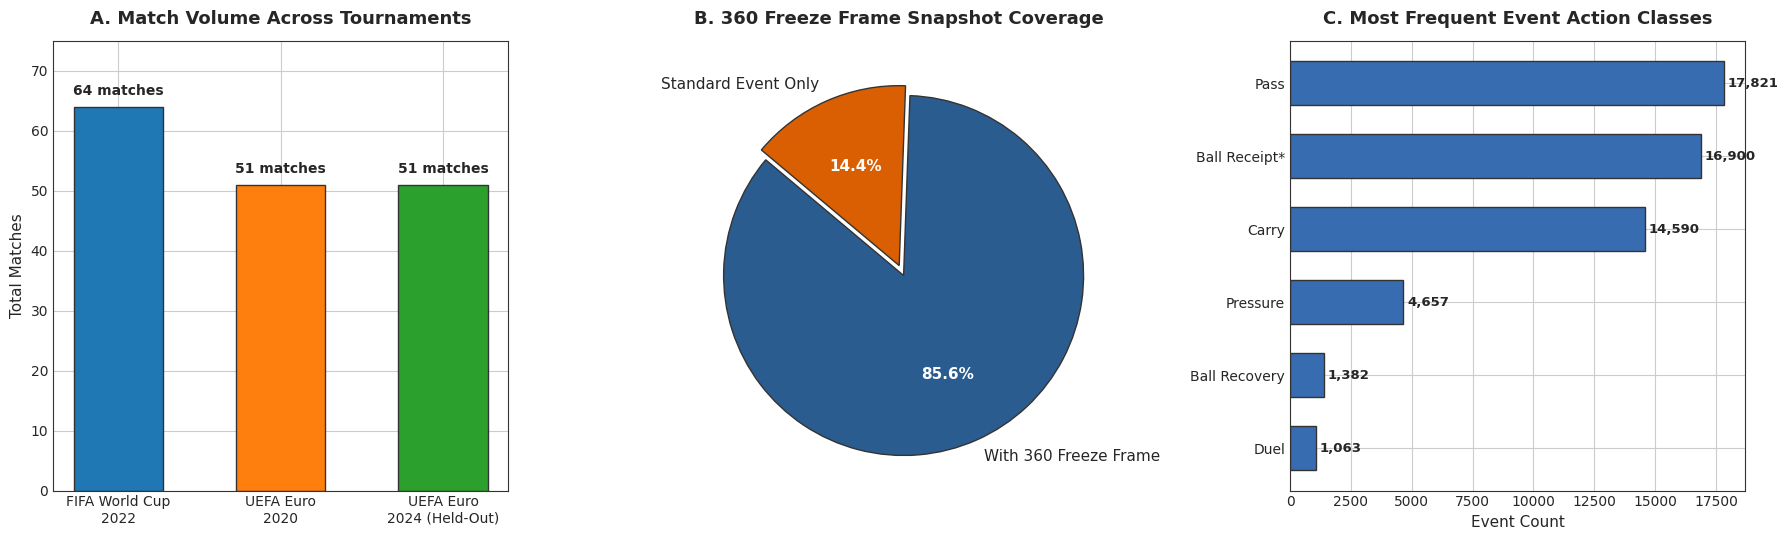

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.patch.set_facecolor('#ffffff')

# 1A: Match Volume
tourn_counts = [len(matches_wc), len(matches_euro), len(matches_euro24)]
tourn_names = ['FIFA World Cup\n2022', 'UEFA Euro\n2020', 'UEFA Euro\n2024 (Held-Out)']
colors_tourn = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars = axes[0].bar(tourn_names, tourn_counts, color=colors_tourn, width=0.55, edgecolor='#333', linewidth=1)
axes[0].set_title('A. Match Volume Across Tournaments', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Total Matches', fontsize=11)
axes[0].set_ylim(0, 75)
for bar in bars:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f'{int(yval)} matches', ha='center', va='bottom', fontweight='bold', fontsize=10)

# 1B: 360 Coverage
labels_360 = ['With 360 Freeze Frame', 'Standard Event Only']
counts_360 = [df_events['has_360'].sum(), len(df_events) - df_events['has_360'].sum()]
colors_pie = ['#2b5c8f', '#d95f02']
wedges, texts, autotexts = axes[1].pie(counts_360, labels=labels_360, autopct='%1.1f%%', colors=colors_pie, startangle=140,
                                       explode=(0.06, 0), textprops={'fontsize': 11},
                                       wedgeprops={'edgecolor': '#333', 'linewidth': 1})
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
axes[1].set_title('B. 360 Freeze Frame Snapshot Coverage', fontsize=13, fontweight='bold', pad=12)

# 1C: Primary Event Class Distribution
top_events = df_events['type'].value_counts().head(6)
axes[2].barh(top_events.index, top_events.values, color='#386cb0', edgecolor='#333', height=0.6)
axes[2].set_title('C. Most Frequent Event Action Classes', fontsize=13, fontweight='bold', pad=12)
axes[2].set_xlabel('Event Count', fontsize=11)
axes[2].invert_yaxis()
for i, v in enumerate(top_events.values):
    axes[2].text(v + 150, i, f'{v:,}', va='center', fontweight='bold', fontsize=9.5)
    
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig1_dataset_architecture_and_coverage.png'), dpi=300, bbox_inches='tight')
plt.show()


## Step 9: Figure 2 — Pitch Spatial Event Density & Tactical Zones

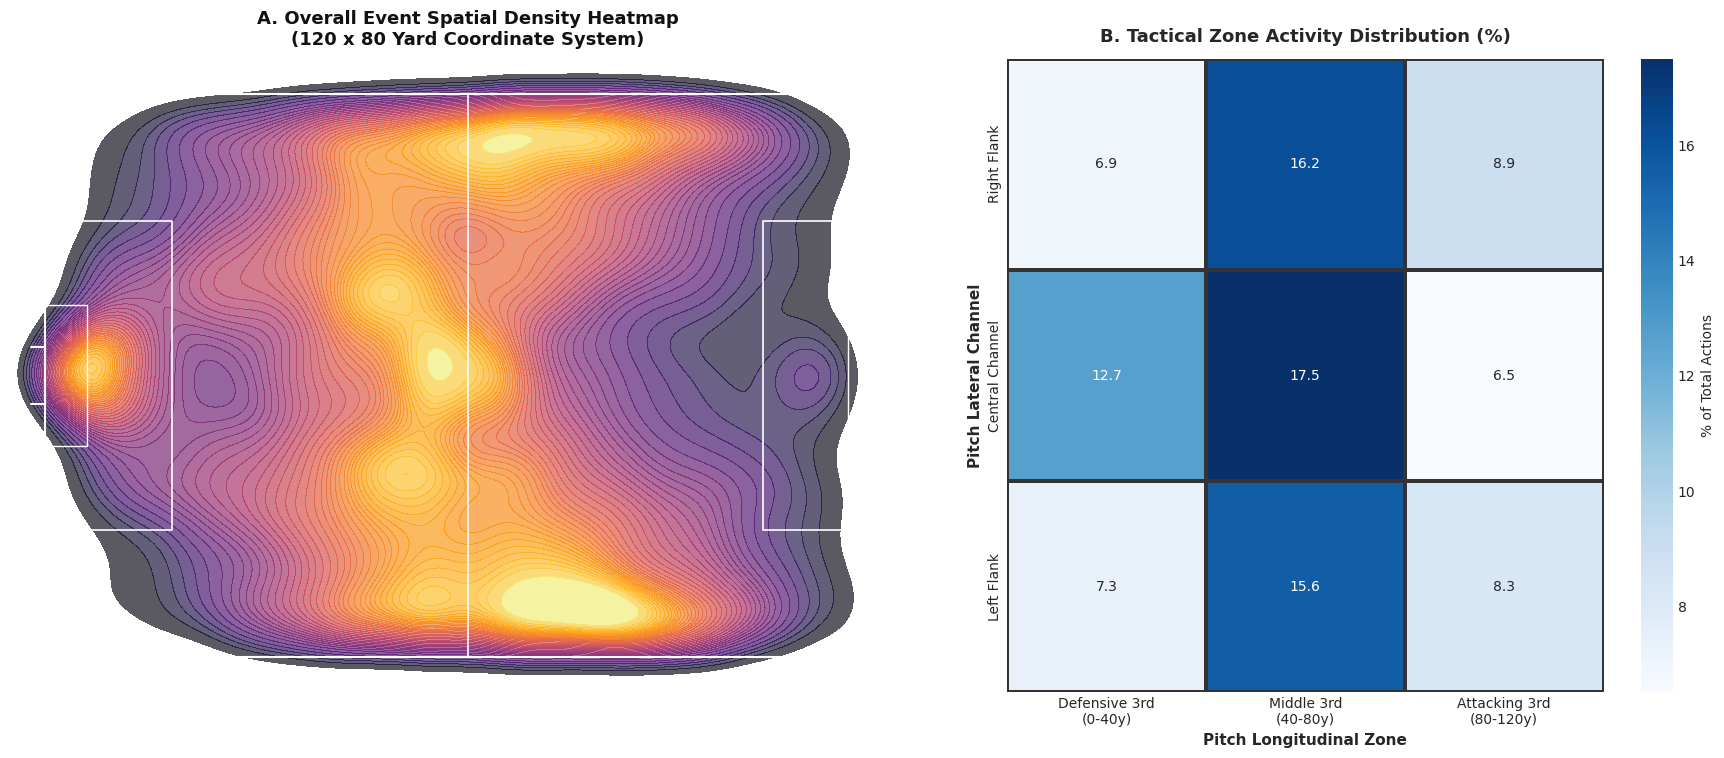

In [9]:
fig, (ax_pitch, ax_zones) = plt.subplots(1, 2, figsize=(18, 7.5), gridspec_kw={'width_ratios': [1.3, 1]})
fig.patch.set_facecolor('#ffffff')

draw_pitch(ax_pitch, pitch_color='#0e1e24', line_color='#ffffff')

valid_coords = df_events.dropna(subset=['location_x', 'location_y']).copy()
sns.kdeplot(
    x=valid_coords['location_x'],
    y=valid_coords['location_y'],
    cmap='inferno',
    fill=True,
    thresh=0.05,
    levels=40,
    alpha=0.65,
    ax=ax_pitch
)
ax_pitch.set_title('A. Overall Event Spatial Density Heatmap\n(120 x 80 Yard Coordinate System)', fontsize=13, fontweight='bold', color='#111', pad=10)

valid_coords['pitch_third'] = pd.cut(valid_coords['location_x'], bins=[0, 40, 80, 120], labels=['Defensive 3rd\n(0-40y)', 'Middle 3rd\n(40-80y)', 'Attacking 3rd\n(80-120y)'])
valid_coords['pitch_flank'] = pd.cut(valid_coords['location_y'], bins=[0, 25, 55, 80], labels=['Right Flank', 'Central Channel', 'Left Flank'])

zone_cross = pd.crosstab(valid_coords['pitch_flank'], valid_coords['pitch_third'], normalize='all') * 100
sns.heatmap(zone_cross, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': '% of Total Actions'}, ax=ax_zones, linewidths=1.5, linecolor='#333')
ax_zones.set_title('B. Tactical Zone Activity Distribution (%)', fontsize=13, fontweight='bold', pad=12)
ax_zones.set_xlabel('Pitch Longitudinal Zone', fontsize=11, fontweight='bold')
ax_zones.set_ylabel('Pitch Lateral Channel', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig2_spatial_event_density_and_pitch_zones.png'), dpi=300, bbox_inches='tight')
plt.show()


## Step 10: Figure 3 — 360 Freeze Frame Density, Proximity Pressure & Goal Cone Blockers

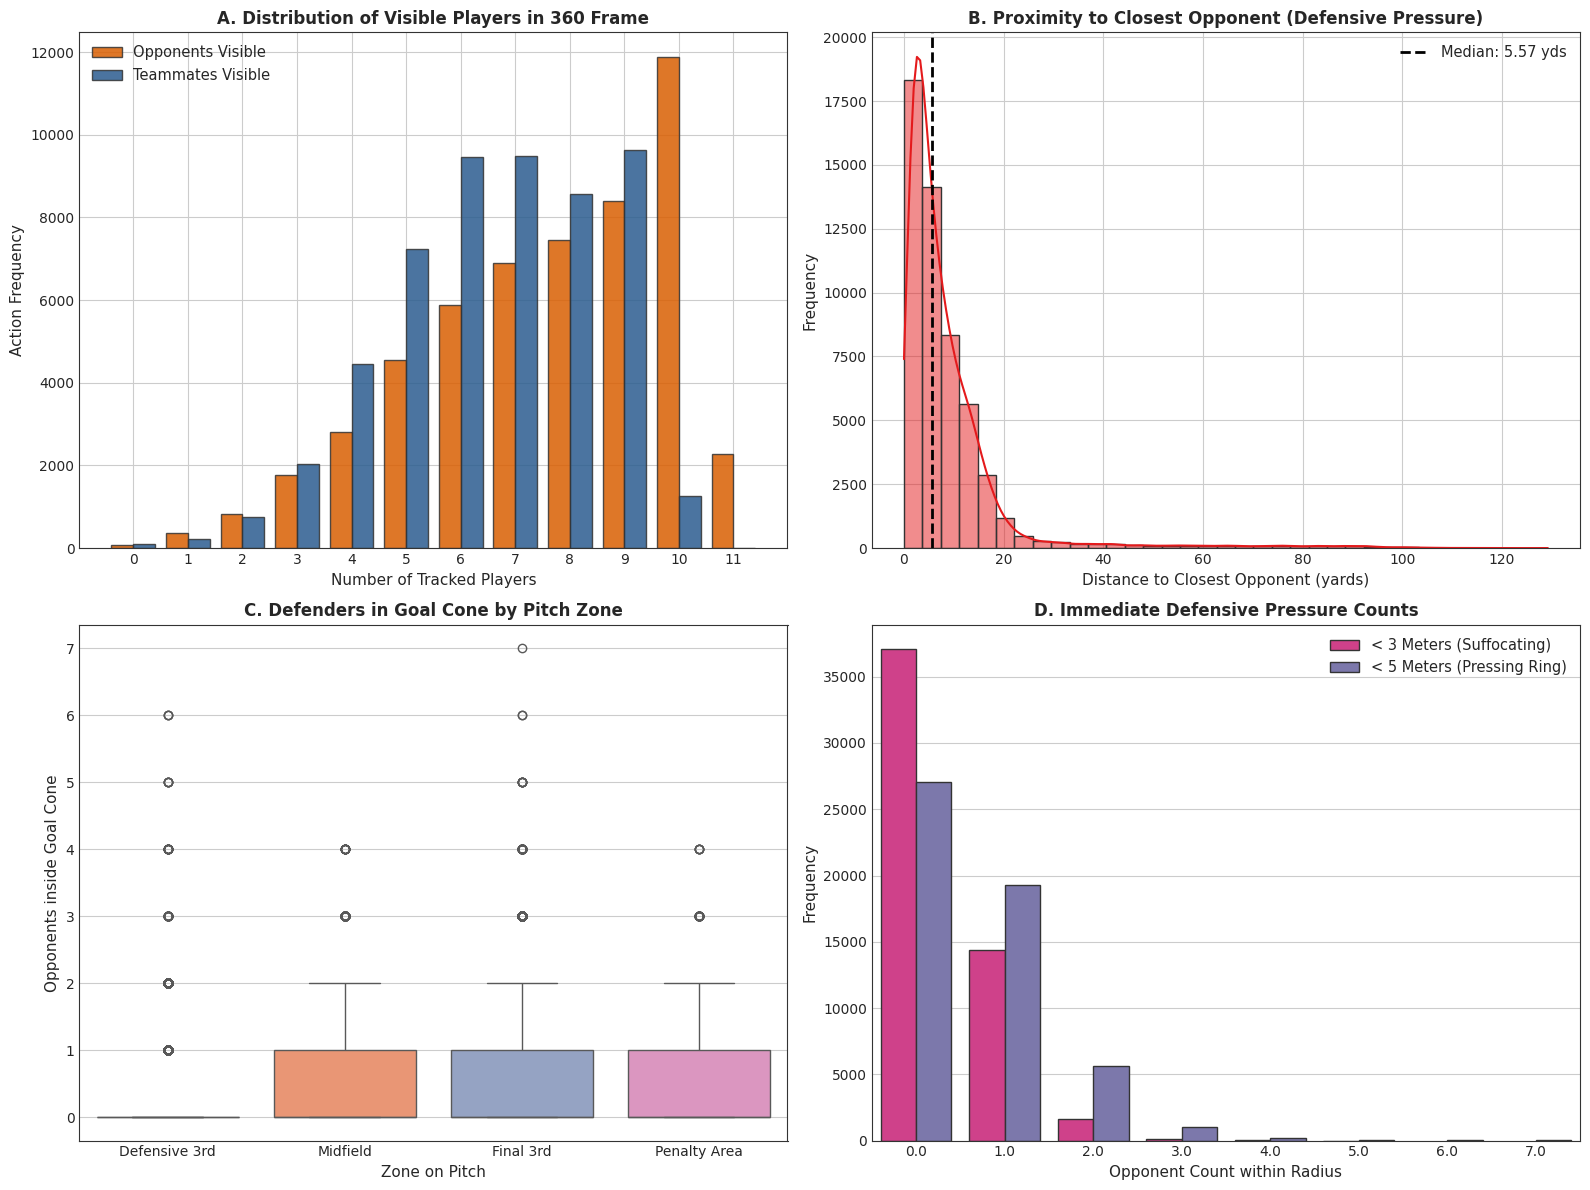

In [10]:
events_360 = df_events[df_events['has_360'] == True].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#ffffff')

# 3A: Opponents vs Teammates Visible
axes[0, 0].hist([events_360['opponents_visible'].dropna(), events_360['teammates_visible'].dropna()], 
                bins=np.arange(0, 13) - 0.5, label=['Opponents Visible', 'Teammates Visible'], 
                color=['#d95f02', '#2b5c8f'], edgecolor='#333', alpha=0.85)
axes[0, 0].set_title('A. Distribution of Visible Players in 360 Frame', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Number of Tracked Players', fontsize=11)
axes[0, 0].set_ylabel('Action Frequency', fontsize=11)
axes[0, 0].set_xticks(range(0, 12))
axes[0, 0].legend(fontsize=10.5)

# 3B: Closest Opponent Proximity
sns.histplot(events_360['closest_opp_dist'].dropna(), bins=35, kde=True, color='#e41a1c', ax=axes[0, 1], edgecolor='#333')
axes[0, 1].axvline(events_360['closest_opp_dist'].median(), color='black', linestyle='--', linewidth=2, label=f'Median: {events_360["closest_opp_dist"].median():.2f} yds')
axes[0, 1].set_title('B. Proximity to Closest Opponent (Defensive Pressure)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Distance to Closest Opponent (yards)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].legend(fontsize=10.5)

# 3C: Defenders in Goal Cone vs Pitch Zone
events_360['pitch_zone_coarse'] = pd.cut(events_360['location_x'], bins=[0, 40, 80, 102, 120], labels=['Defensive 3rd', 'Midfield', 'Final 3rd', 'Penalty Area'])
sns.boxplot(x='pitch_zone_coarse', y='defenders_in_goal_cone', data=events_360, palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('C. Defenders in Goal Cone by Pitch Zone', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Zone on Pitch', fontsize=11)
axes[1, 0].set_ylabel('Opponents inside Goal Cone', fontsize=11)

# 3D: Immediate Pressure Suffocation Rings
opp_press_df = events_360[['opponents_within_3m', 'opponents_within_5m']].melt(var_name='Radius', value_name='Count')
opp_press_df['Radius'] = opp_press_df['Radius'].replace({'opponents_within_3m': '< 3 Meters (Suffocating)', 'opponents_within_5m': '< 5 Meters (Pressing Ring)'})
sns.countplot(x='Count', hue='Radius', data=opp_press_df, palette=['#e7298a', '#7570b3'], ax=axes[1, 1], edgecolor='#333')
axes[1, 1].set_title('D. Immediate Defensive Pressure Counts', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Opponent Count within Radius', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].legend(fontsize=10.5)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig3_statsbomb360_freeze_frame_pressure.png'), dpi=300, bbox_inches='tight')
plt.show()


## Step 11: Figure 4 — Action Dynamics, Passing Angles & Possession Chains

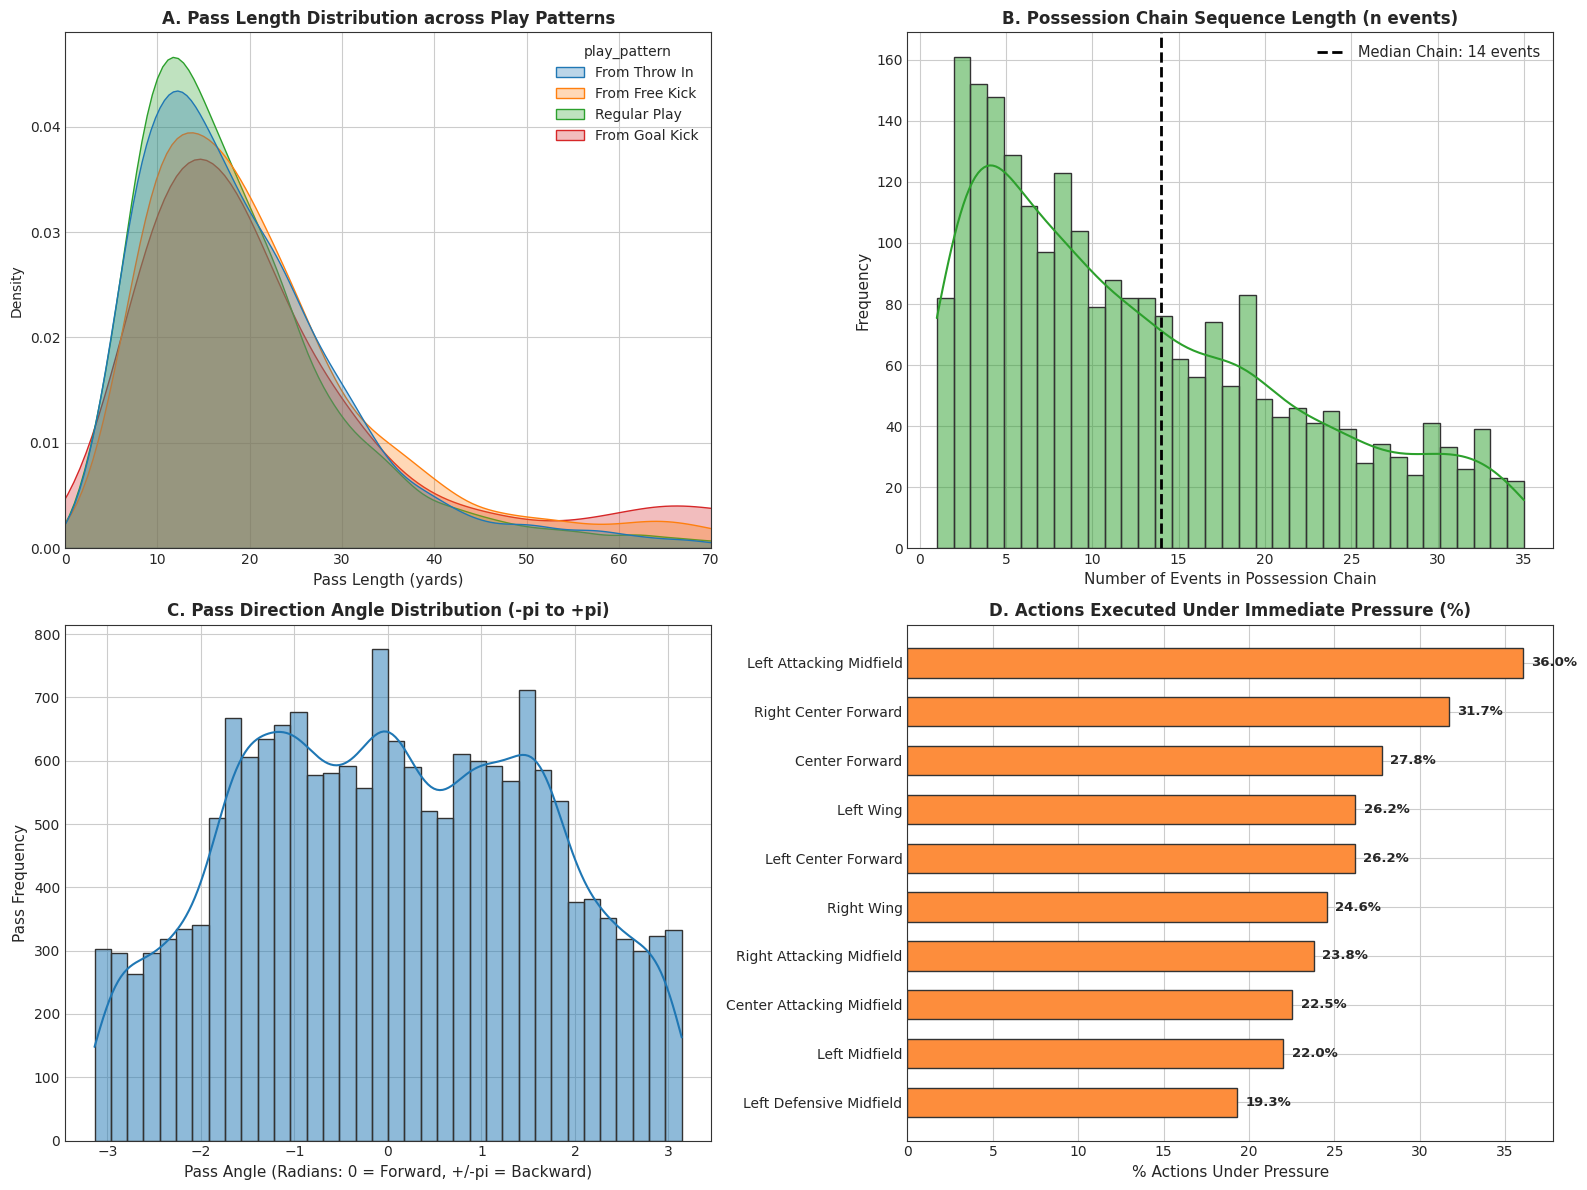

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#ffffff')

# 4A: Pass Length Distribution
passes_df = df_events[df_events['type'] == 'Pass'].dropna(subset=['pass_length', 'play_pattern']).copy()
top_patterns = passes_df['play_pattern'].value_counts().head(4).index
sns.kdeplot(data=passes_df[passes_df['play_pattern'].isin(top_patterns)], x='pass_length', hue='play_pattern', common_norm=False, fill=True, alpha=0.3, ax=axes[0, 0])
axes[0, 0].set_title('A. Pass Length Distribution across Play Patterns', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Pass Length (yards)', fontsize=11)
axes[0, 0].set_xlim(0, 70)

# 4B: Possession Chain Lengths
possession_lengths = df_events.groupby(['match_id', 'possession'])['event_id'].count()
sns.histplot(possession_lengths[possession_lengths <= 35], bins=35, kde=True, color='#2ca02c', ax=axes[0, 1], edgecolor='#333')
axes[0, 1].axvline(possession_lengths.median(), color='black', linestyle='--', linewidth=2, label=f'Median Chain: {possession_lengths.median():.0f} events')
axes[0, 1].set_title('B. Possession Chain Sequence Length (n events)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Number of Events in Possession Chain', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].legend(fontsize=10.5)

# 4C: Pass Direction Angles
sns.histplot(passes_df['pass_angle'].dropna(), bins=36, kde=True, color='#1f77b4', ax=axes[1, 0], edgecolor='#333')
axes[1, 0].set_title('C. Pass Direction Angle Distribution (-pi to +pi)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Pass Angle (Radians: 0 = Forward, +/-pi = Backward)', fontsize=11)
axes[1, 0].set_ylabel('Pass Frequency', fontsize=11)

# 4D: Under Pressure by Position Group
pos_pressure = df_events.groupby('position')['under_pressure'].mean().sort_values(ascending=False).head(10) * 100
axes[1, 1].barh(pos_pressure.index, pos_pressure.values, color='#fd8d3c', edgecolor='#333', height=0.6)
axes[1, 1].set_title('D. Actions Executed Under Immediate Pressure (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('% Actions Under Pressure', fontsize=11)
axes[1, 1].invert_yaxis()
for i, v in enumerate(pos_pressure.values):
    axes[1, 1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold', fontsize=9.5)
    
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig4_action_types_and_possession_chains.png'), dpi=300, bbox_inches='tight')
plt.show()


## Step 12: Figure 5 — Feature Correlation Matrix & Spatial Interdependence

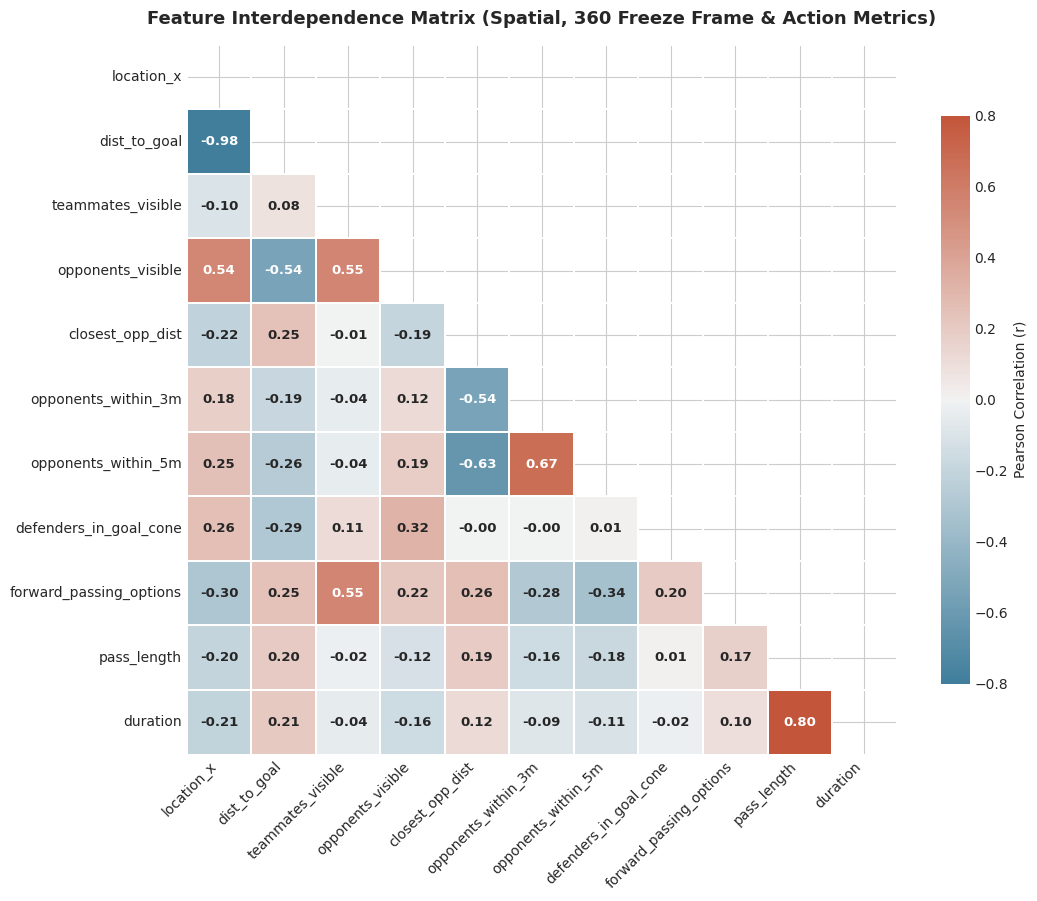

In [12]:
corr_features = [
    'location_x', 'dist_to_goal', 'teammates_visible', 'opponents_visible',
    'closest_opp_dist', 'opponents_within_3m', 'opponents_within_5m',
    'defenders_in_goal_cone', 'forward_passing_options', 'pass_length', 'duration'
]
corr_df = df_events[corr_features].dropna().corr()
corr_df.to_csv(os.path.join(DATA_DIR, 'feature_correlation_matrix.csv'))

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('#ffffff')

mask = np.triu(np.ones_like(corr_df, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_df, mask=mask, cmap=cmap, vmin=-0.8, vmax=0.8, center=0,
            square=True, linewidths=1.2, linecolor='#ffffff', cbar_kws={'shrink': .8, 'label': 'Pearson Correlation (r)'},
            annot=True, fmt='.2f', annot_kws={'size': 9.5, 'weight': 'bold'}, ax=ax)
ax.set_title('Feature Interdependence Matrix (Spatial, 360 Freeze Frame & Action Metrics)', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig5_feature_correlation_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()


## Step 13: Figure 6 — Catalytic Play Indicators & Top Players Under Pressure

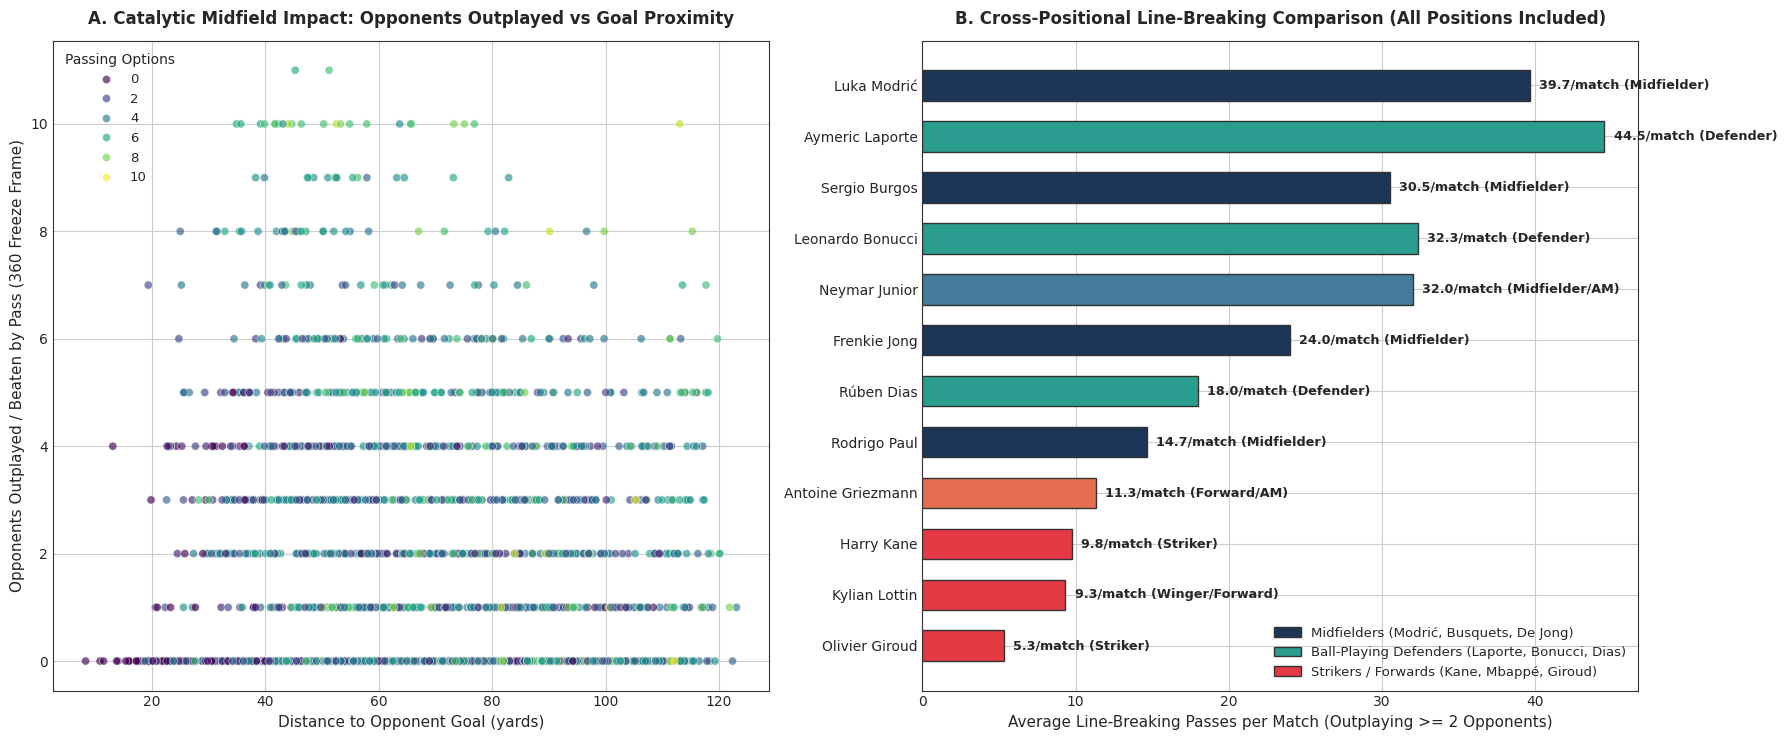

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
fig.patch.set_facecolor('#ffffff')

# 6A: Midfield Line-Breaking Pass Distribution vs Goal Proximity
passes_360 = events_360[events_360['type'] == 'Pass'].copy()
sns.scatterplot(
    data=passes_360.sample(min(2500, len(passes_360)), random_state=42),
    x='dist_to_goal',
    y='opponents_eliminated',
    hue='forward_passing_options',
    palette='viridis',
    alpha=0.65,
    s=35,
    ax=axes[0]
)
axes[0].set_title('A. Catalytic Midfield Impact: Opponents Outplayed vs Goal Proximity', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Distance to Opponent Goal (yards)', fontsize=11)
axes[0].set_ylabel('Opponents Outplayed / Beaten by Pass (360 Freeze Frame)', fontsize=11)
axes[0].legend(title='Passing Options', fontsize=9.5, title_fontsize=10)

# 6B: Cross-Positional Comparison across All Positions (Midfielders vs Defenders vs Forwards)
p_stats = passes_360.groupby('player').agg(
    total_passes=('event_id', 'count'),
    total_beaten=('opponents_eliminated', 'sum'),
    line_breaking_passes=('line_breaking_pass', 'sum'),
    matches=('match_id', 'nunique'),
    position=('position', 'first')
)
p_stats['line_breaking_per_match'] = p_stats['line_breaking_passes'] / p_stats['matches']

selected_players = [
    ('Luka Modrić', 'Midfielder', '#1d3557'),
    ('Aymeric Laporte', 'Defender', '#2a9d8f'),
    ('Sergio Busquets i Burgos', 'Midfielder', '#1d3557'),
    ('Leonardo Bonucci', 'Defender', '#2a9d8f'),
    ('Neymar da Silva Santos Junior', 'Midfielder/AM', '#457b9d'),
    ('Frenkie de Jong', 'Midfielder', '#1d3557'),
    ('Rúben Santos Gato Alves Dias', 'Defender', '#2a9d8f'),
    ('Rodrigo Javier De Paul', 'Midfielder', '#1d3557'),
    ('Antoine Griezmann', 'Forward/AM', '#e76f51'),
    ('Harry Kane', 'Striker', '#e63946'),
    ('Kylian Mbappé Lottin', 'Winger/Forward', '#e63946'),
    ('Olivier Giroud', 'Striker', '#e63946'),
]

plot_data = []
for p, role, color in selected_players:
    if p in p_stats.index:
        val = p_stats.loc[p, 'line_breaking_per_match']
        plot_data.append({'Player': p.split(' ')[0] + ' ' + p.split(' ')[-1], 'Role': role, 'Rate': val, 'Color': color})

p_df = pd.DataFrame(plot_data)

bars = axes[1].barh(p_df['Player'], p_df['Rate'], color=p_df['Color'], edgecolor='#333', height=0.6)
axes[1].set_title('B. Cross-Positional Line-Breaking Comparison (All Positions Included)', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Average Line-Breaking Passes per Match (Outplaying >= 2 Opponents)', fontsize=11)
axes[1].invert_yaxis()

for i, row in p_df.iterrows():
    axes[1].text(row['Rate'] + 0.6, i, f"{row['Rate']:.1f}/match ({row['Role']})", va='center', fontweight='bold', fontsize=9.2)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1d3557', edgecolor='#333', label='Midfielders (Modrić, Busquets, De Jong)'),
    Patch(facecolor='#2a9d8f', edgecolor='#333', label='Ball-Playing Defenders (Laporte, Bonucci, Dias)'),
    Patch(facecolor='#e63946', edgecolor='#333', label='Strikers / Forwards (Kane, Mbappé, Giroud)'),
]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=9.5, framealpha=0.95)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig6_player_spatial_profiles_and_vaep_indicators.png'), dpi=300, bbox_inches='tight')
plt.show()
